In [2]:
!pip install scikit-learn

                                              0.0/8.1 MB ? eta -:--:--
                                              0.0/8.1 MB 653.6 kB/s eta 0:00:13
                                              0.2/8.1 MB 2.1 MB/s eta 0:00:04
     --                                       0.4/8.1 MB 3.3 MB/s eta 0:00:03
     ---                                      0.8/8.1 MB 4.2 MB/s eta 0:00:02
     ------                                   1.3/8.1 MB 5.9 MB/s eta 0:00:02
     --------                                 1.8/8.1 MB 6.7 MB/s eta 0:00:01
     -----------                              2.3/8.1 MB 7.2 MB/s eta 0:00:01
     --------------                           2.9/8.1 MB 8.0 MB/s eta 0:00:01
     -----------------                        3.5/8.1 MB 8.5 MB/s eta 0:00:01
     --------------------                     4.1/8.1 MB 9.1 MB/s eta 0:00:01
     -----------------------                  4.8/8.1 MB 9.6 MB/s eta 0:00:01
     ---------------------------              5.5/8.1 MB 10.1 MB/s et


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [5]:
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [6]:
# Remove matches with no result
matches = matches[matches['winner'].notna()]

# Fix team names (important)
matches.replace('Delhi Daredevils', 'Delhi Capitals', inplace=True)
matches.replace('Deccan Chargers', 'Sunrisers Hyderabad', inplace=True)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4.0,215.0,20.0,N,NaN,Nitin Menon,VK Sharma
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,160.0,20.0,N,NaN,AK Chaudhary,R Pandit
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,4.0,173.0,20.0,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36.0,176.0,20.0,N,NaN,Nitin Menon,VK Sharma


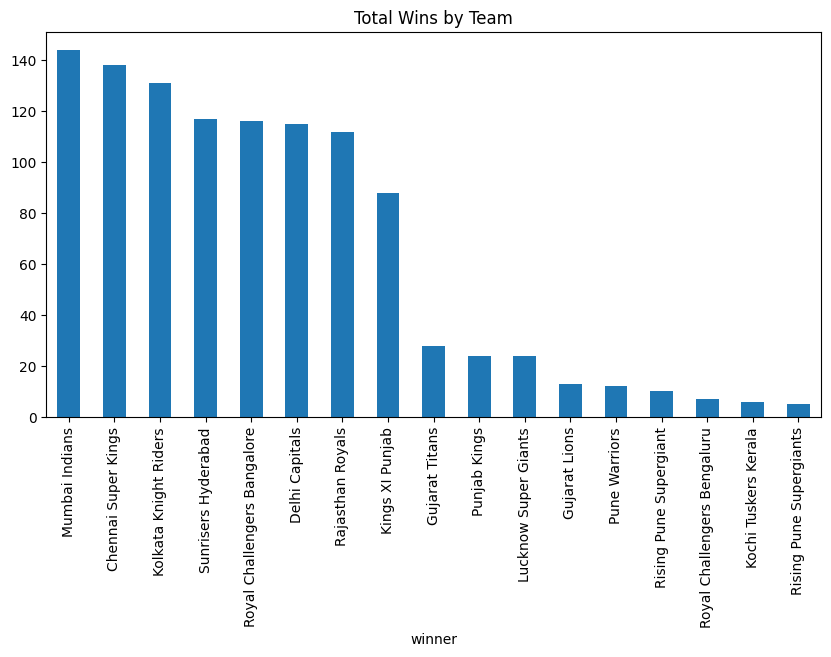

In [7]:
# Most wins by team
plt.figure(figsize=(10,5))
matches['winner'].value_counts().plot(kind='bar')
plt.title("Total Wins by Team")
plt.show()

In [8]:
data = matches[['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'winner']]

In [9]:
le = LabelEncoder()

for col in data.columns:
    data[col] = le.fit_transform(data[col])

In [10]:
X = data.drop('winner', axis=1)
y = data['winner']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [11]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
y_pred = model.predict(X_test)

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.47706422018348627


In [14]:
print(confusion_matrix(y_test, y_pred))

[[20  2  0  0  0  0  1  0  2  0  0  0  0  1  0  0]
 [ 1  9  0  0  0  0  1  2  4  0  2  0  0  1  0  4]
 [ 0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 1  1  0  1  0  0  0  0  0  0  0  1  0  0  0  0]
 [ 2  1  2  0  5  0  2  0  1  1  0  0  0  5  0  1]
 [ 0  0  0  0  1  0  1  0  0  0  0  0  0  0  0  0]
 [ 2  1  0  0  2  0 18  1  1  0  0  2  0  2  0  1]
 [ 0  0  0  0  0  0  0  3  0  0  0  0  0  0  0  0]
 [ 2  1  0  1  3  0  1  0 14  0  0  0  0  2  0  4]
 [ 1  0  0  0  0  0  0  0  2  0  0  0  0  0  0  0]
 [ 2  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0]
 [ 2  2  0  0  2  0  1  0  3  0  1 13  0  0  0  4]
 [ 0  0  0  0  0  0  0  0  0  0  0  2  1  0  0  0]
 [ 2  4  1  0  2  0  0  0  6  0  0  2  0  6  0  0]
 [ 0  0  0  0  0  0  0  1  0  0  0  0  0  0  1  0]
 [ 1  1  0  0  2  0  0  0  0  0  0  0  0  2  0 12]]


In [15]:
model.feature_importances_

array([0.23798187, 0.2302359 , 0.19197331, 0.05634143, 0.28346749])

In [16]:
# Calculate win probability based on historical wins
win_counts = matches['winner'].value_counts()

# Convert to DataFrame
win_df = win_counts.reset_index()
win_df.columns = ['Team', 'Wins']

# Convert to probability
win_df['Win_Percentage'] = (win_df['Wins'] / win_df['Wins'].sum()) * 100

win_df.head()

,Team,Wins,Win_Percentage
0,Mumbai Indians,144,13.211009
1,Chennai Super Kings,138,12.660550
2,Kolkata Knight Riders,131,12.018349
3,Sunrisers Hyderabad,117,10.733945
4,Royal Challengers Bangalore,116,10.642202


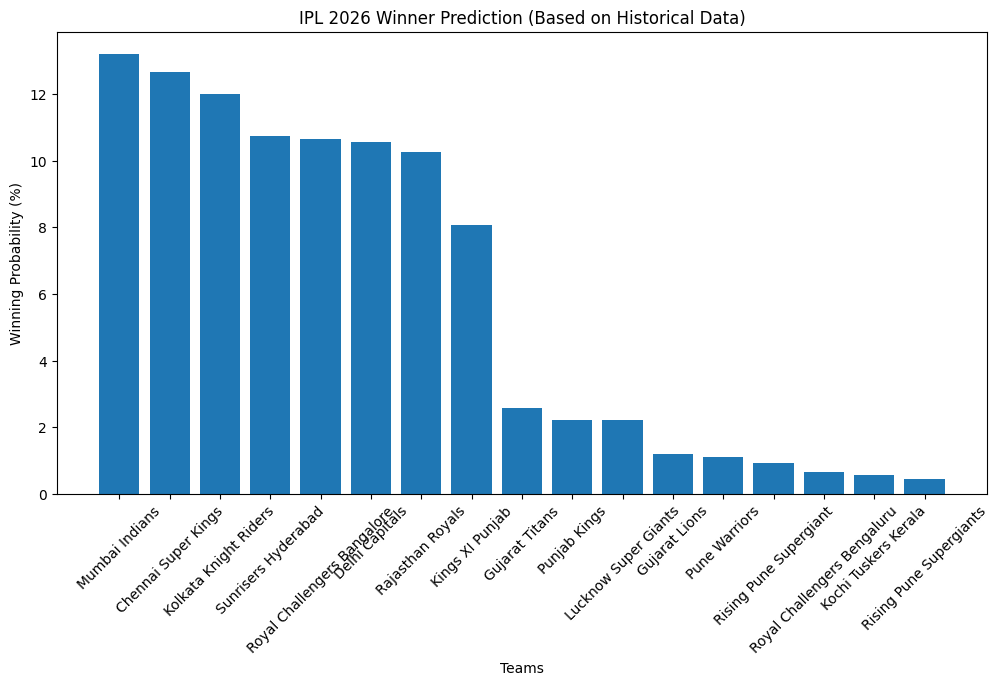

In [17]:
plt.figure(figsize=(12,6))
plt.bar(win_df['Team'], win_df['Win_Percentage'])

plt.xticks(rotation=45)
plt.title("IPL 2026 Winner Prediction (Based on Historical Data)")
plt.xlabel("Teams")
plt.ylabel("Winning Probability (%)")

plt.show()

In [18]:
top_team = win_df.iloc[0]['Team']
top_prob = win_df.iloc[0]['Win_Percentage']

print(f"🏆 Predicted IPL 2026 Winner: {top_team}")
print(f"🔥 Winning Probability: {top_prob:.2f}%")

🏆 Predicted IPL 2026 Winner: Mumbai Indians
🔥 Winning Probability: 13.21%


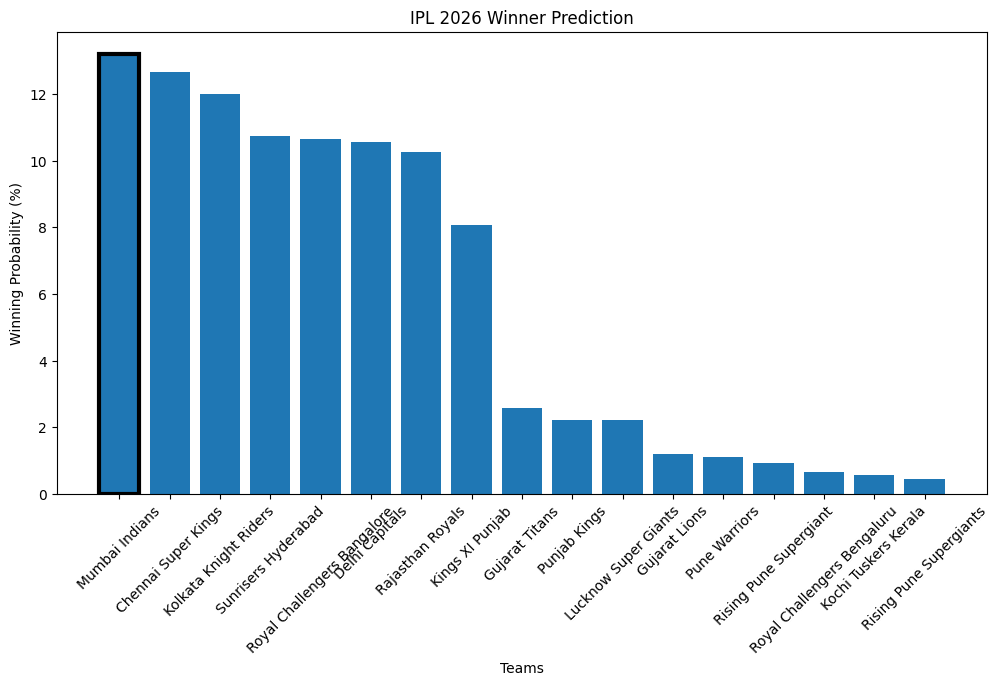

In [19]:
plt.figure(figsize=(12,6))

bars = plt.bar(win_df['Team'], win_df['Win_Percentage'])

# Highlight top team
bars[0].set_edgecolor('black')
bars[0].set_linewidth(3)

plt.xticks(rotation=45)
plt.title("IPL 2026 Winner Prediction")
plt.xlabel("Teams")
plt.ylabel("Winning Probability (%)")

plt.show()